# 6 &middot; Drift on the Lightcone

A lightcone shell is a radial bin of the simulation. The simplest way to paint it freezes
**every** particle in the bin at one snapshot scale factor $a_c$ (the bin centre). That is exact
only for an infinitely thin shell — across a *thick* shell the near edge is more evolved (lower
redshift) and the far edge less evolved (higher redshift), yet both are forced to the same epoch.

**Drift on the lightcone** removes this approximation: each particle is moved to the scale factor
at which it actually crosses the lightcone,

$$a_{\rm cross} = a\big(\chi = \lVert \mathbf{x} - \mathbf{x}_{\rm obs}\rVert\big),$$

using the solver's own symplectic drift operator. It is a small (sub-Mpc) per-particle move along
the velocity. The kernels that apply it are `DriftInterp` (in-box) and `OnionTiler` /
`TelephotoInterp` with `drift_on_lightcone=True` (beyond the box); `NoInterp` never drifts.
Reference: MADLens ([arXiv:2012.07266](https://arxiv.org/abs/2012.07266)) and FastPM.

This notebook looks at the **density field only**. (The drift does *not* improve Born convergence
$\kappa$ — that error is dominated by the radial line-of-sight projection, not by the per-shell
redshift assignment; see the lensing notebook.)

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import numpy as np

print(f"Devices: {jax.devices()}")

/lustre/fswork/projects/rech/tkc/commun/venv/pm/lib/python3.11/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(


E0610 15:12:14.993322  459318 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0610 15:12:14.993841  459317 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0610 15:12:14.993926  459316 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


Devices: [CudaDevice(id=0)]


## Configuration

We use **one** set of initial conditions for everything below, so every comparison is
cosmic-variance-free: any difference between "with drift" and "without drift" is the drift itself,
not a different random realization. The configuration below is the **production** resolution
($512^3$ mesh, `nside` 512); the figures below are committed from a full **GPU / cluster** run at
this resolution.

In [2]:
key = jax.random.PRNGKey(7)
mesh_size = (512, 512, 512)
box_size = (2400.0, 2400.0, 2400.0)
nside = 512
n_steps = 16
cosmo = jc.Planck18()
LMAX = 2 * nside


def make_solver(interp):
    return jfli.DoubleKickDrift(interp_kernel=interp, t0=0.1, t1=1.0, n_steps=n_steps)


def a_of_chi(chi):
    return np.asarray(jc.background.a_of_chi(cosmo, jnp.atleast_1d(jnp.asarray(chi))))


def z_of(chi):
    return 1.0 / a_of_chi(chi) - 1.0

## Initial conditions & LPT

A single Gaussian realization, advanced to the LPT starting redshift. The displacement `dx` and
momentum `p` feed every lightcone below.

In [3]:
ic = jfli.gaussian_initial_conditions(key, mesh_size, box_size, cosmo=cosmo, nside=nside)
dx, p = jfli.lpt(cosmo, ic, ts=0.1, order=1)
print("box half-width (no-tiling radius):", float(ic.max_comoving_radius), "Mpc/h")

box half-width (no-tiling radius): 1200.0 Mpc/h


## 1 &middot; What the drift does to redshift assignment

The clearest picture is a single **thick** radial bin, painted as particles. **Both panels below
show the same particle positions**; only the **colour** — the redshift each particle is assigned —
differs:

- **Left — without drift:** the bin is treated as a few discrete sub-shells, and every particle
  takes its sub-shell's centre redshift. The result is a set of colour *bands* — the
  "same redshift across the whole shell" approximation.
- **Right — with drift:** each particle is assigned the redshift of its own comoving radius,
  $z(r)$, giving a smooth radial gradient — the true lightcone.

The drift's effect on the *positions* themselves is sub-Mpc (shown in the next cell); here we are
only illustrating the redshift assignment.

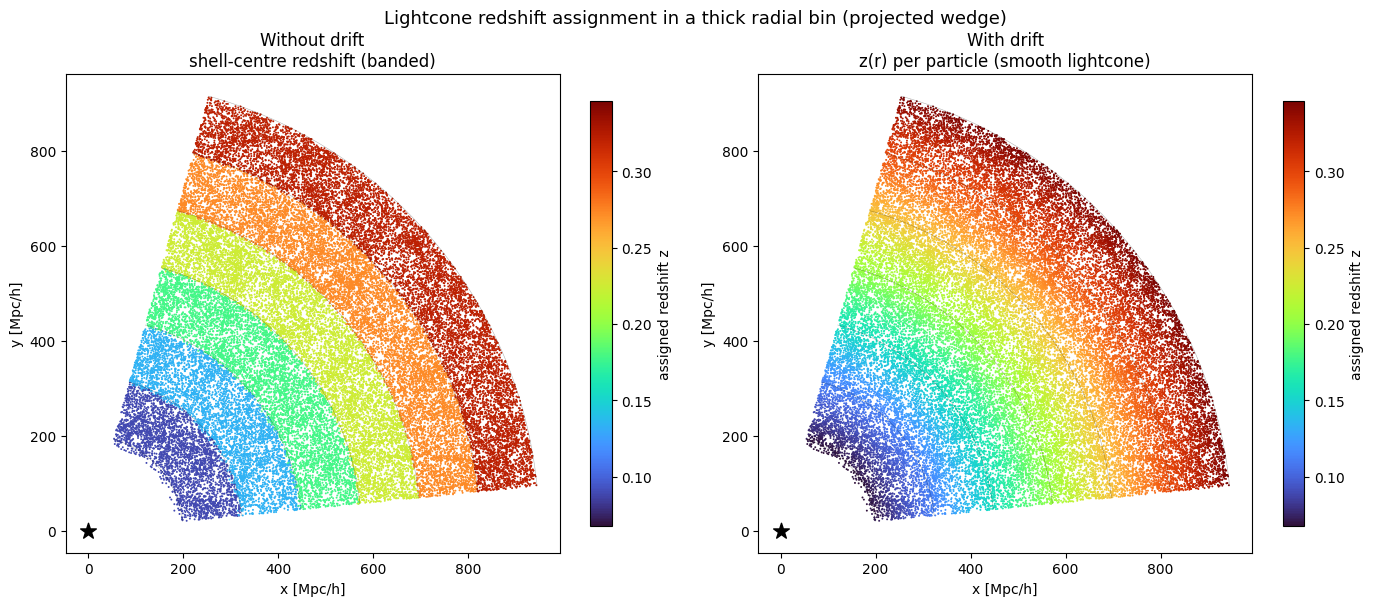

In [4]:
# A single thick radial bin (inside the box half-width, so no tiling), painted as particles.
R0, R1 = 200.0, 950.0
rc = 0.5 * (R0 + R1)
a_c = float(a_of_chi(rc)[0])
part = jfli.PaintingOptions(target="particles")

pf_no = jfli.nbody(
    cosmo,
    dx,
    p,
    solver=make_solver(jfli.NoInterp(painting=part)),
    ts=jnp.array([a_c]),
    density_widths=jnp.array([R1 - R0]),
    shell_spacing="comoving",
    min_width=1.0,
)
pf_dr = jfli.nbody(
    cosmo,
    dx,
    p,
    solver=make_solver(jfli.DriftInterp(painting=part)),
    ts=jnp.array([a_c]),
    density_widths=jnp.array([R1 - R0]),
    shell_spacing="comoving",
    min_width=1.0,
)

obs = 0.5 * np.array(box_size)  # observer at the box centre (default)
pos_no = np.asarray(pf_no.to(jfli.PositionUnit.MPC_H).array).reshape(-1, 3) - obs
pos_dr = np.asarray(pf_dr.to(jfli.PositionUnit.MPC_H).array).reshape(-1, 3) - obs
r_no = np.linalg.norm(pos_no, axis=1)

# thin slab + angular wedge -> legible 2D projection
phi = np.arctan2(pos_no[:, 1], pos_no[:, 0])
sel = (np.abs(pos_no[:, 2]) < 80.0) & (phi > 0.1) & (phi < 1.3) & (r_no > R0) & (r_no < R1)
idx = np.where(sel)[0]
rng = np.random.default_rng(0)
if idx.size > 40000:
    idx = rng.choice(idx, 40000, replace=False)
x, y, r_sel = pos_no[idx, 0], pos_no[idx, 1], r_no[idx]

N_SHELLS = 6
edges = np.linspace(R0, R1, N_SHELLS + 1)
shell_idx = np.clip(np.digitize(r_sel, edges) - 1, 0, N_SHELLS - 1)
z_band = (z_of(0.5 * (edges[:-1] + edges[1:])))[shell_idx]  # banded: shell-centre z
z_smooth = z_of(r_sel)  # smooth: z(r)

fig = plt.figure(figsize=(14, 6))
vmin, vmax = float(z_smooth.min()), float(z_smooth.max())
for col, (z, title) in enumerate(
    [
        (z_band, "Without drift\nshell-centre redshift (banded)"),
        (z_smooth, "With drift\nz(r) per particle (smooth lightcone)"),
    ]
):
    ax = fig.add_subplot(1, 2, col + 1)
    sc = ax.scatter(x, y, c=z, s=2, cmap="turbo", vmin=vmin, vmax=vmax, linewidths=0)
    for e in edges:
        ang = np.linspace(0.1, 1.3, 100)
        ax.plot(e * np.cos(ang), e * np.sin(ang), color="k", lw=0.4, alpha=0.3)
    ax.scatter([0], [0], marker="*", c="k", s=140, zorder=5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x [Mpc/h]")
    ax.set_ylabel("y [Mpc/h]")
    plt.colorbar(sc, ax=ax, label="assigned redshift z", shrink=0.8)
fig.suptitle("Lightcone redshift assignment in a thick radial bin (projected wedge)", fontsize=13)
fig.tight_layout()
plt.show()

### How far does the drift actually move particles?

The drift is a linear (Zel'dovich) continuation of the trajectory to the crossing epoch, so it is
small — sub-Mpc for most particles. This is why it visibly *re-labels* the redshift of a shell but
barely changes the projected angular map: a sub-Mpc radial move is far below a HEALPix pixel at
these distances. It matters for the **3-D density** of a thick shell (next section) and is
negligible for the radial $\kappa$ projection.

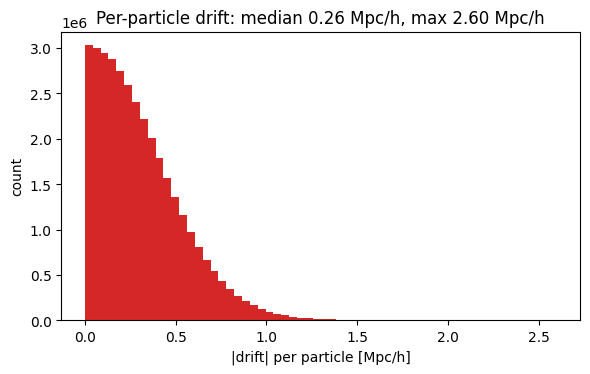

In [5]:
drift = pos_dr - pos_no
dmag = np.linalg.norm(drift, axis=1)
inbin = (r_no > R0) & (r_no < R1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(dmag[inbin], bins=60, color="C3")
ax.set_xlabel("|drift| per particle [Mpc/h]")
ax.set_ylabel("count")
ax.set_title(f"Per-particle drift: median {np.median(dmag[inbin]):.2f} Mpc/h, " f"max {dmag[inbin].max():.2f} Mpc/h")
fig.tight_layout()
plt.show()

## 2 &middot; Density $C_\ell$: the drift halves the number of shells you need

A lightcone is a stack of shells. The frozen-epoch error of a single shell grows with its **width**
$W$, and to cover a fixed depth you need $\#\text{shells} = \text{depth}/W$ — so *thicker* shells
mean *fewer* shells. The drift removes most of the per-shell error, so it reaches a given accuracy
at roughly **twice the width**, i.e. **half as many shells**.

The **reference** throughout is the *same* radial bin painted as a stack of thin ($\sim$50 Mpc/h)
sub-shells, each frozen at its own sub-centre and summed in *counts* — the continuous-lightcone
ground truth. A ratio of $1$ then means "matches the true lightcone." We work at a fixed bin centre
($z\approx0.25$, inside the box so no tiling is needed) and show two views:

- **Panel (a)** sweeps the shell width $W$: one thick shell, with and without drift, each compared
  to *its own* thin reference. The frozen-epoch error climbs with $W$; the drift stays flat.
- **Panel (b)** is the correctly-posed "fewer shells?" test on **one fixed slab**
  ([225, 1175] Mpc/h), with **every curve divided by the same** thin-shell reference of that slab:
  cover it with **1 thick shell** ($W=950$, with and without drift) versus **2 thinner shells**
  ($W=475$, no drift). The "1 / 2 shells" are the $\approx$10 / $\approx$20 shells a deep
  ($\sim$9500 Mpc/h) lightcone would need; here we use one representative slab, not a literal deep
  lightcone (whose box tiling would swamp the sub-Mpc drift).

In [6]:
RC = 700.0  # bin centre [Mpc/h]  (z ~ 0.25, inside the box half-width 1200)
SUBSHELL = 50.0  # thin-reference sub-shell width [Mpc/h]
band = slice(10, LMAX - 5)
SPH = jfli.PaintingOptions(target="spherical", scheme="rbf_neighbor", paint_nside=nside)


def paint(interp, ts, widths):
    return jfli.nbody(
        cosmo,
        dx,
        p,
        solver=make_solver(interp),
        ts=jnp.asarray(ts),
        density_widths=jnp.asarray(widths),
        shell_spacing="comoving",
        min_width=1.0,
    )


# Angular C_ell of a map's overdensity, straight from the field API:
# .to(OVERDENSITY) mean-normalizes (delta = rho/rho_bar - 1), .angular_cl runs the HEALPix
# transform -- no hand-rolled anafast / normalization.
def shell_cl(field):
    ps = field.to(jfli.DensityUnit.OVERDENSITY).angular_cl(method="healpy", lmax=LMAX)
    return np.asarray(ps.array).reshape(-1)


def width_run(W):
    R0w, R1w = RC - W / 2, RC + W / 2
    K = max(2, int(round(W / SUBSHELL)))
    edges = np.linspace(R0w, R1w, K + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # reference: thin sub-shells summed into one slab. Sum COUNTS (per-pixel volume differs
    # between sub-shells); the COUNTS -> OVERDENSITY conversion then cancels that volume, so the
    # field gives the correct slab overdensity C_ell directly.
    thin = paint(jfli.NoInterp(painting=SPH), a_of_chi(centers), np.diff(edges)).to(jfli.DensityUnit.COUNTS)
    ref = thin.replace(
        array=thin.array.sum(axis=0, keepdims=True), comoving_centers=jnp.asarray([RC]), density_width=jnp.asarray([W])
    )
    no = paint(jfli.NoInterp(painting=SPH), [a_of_chi(RC)[0]], [W])
    dr = paint(jfli.DriftInterp(painting=SPH), [a_of_chi(RC)[0]], [W])
    clr, cln, cld = shell_cl(ref), shell_cl(no), shell_cl(dr)
    return dict(
        W=W,
        clr=clr,
        cln=cln,
        cld=cld,
        dev_no=float(np.median(cln[band] / clr[band]) - 1),
        dev_dr=float(np.median(cld[band] / clr[band]) - 1),
    )

In [7]:
WIDTHS = [150.0, 300.0, 475.0, 700.0, 950.0]
res = {W: width_run(W) for W in WIDTHS}

print("shell width   no drift   with drift   (median C_l deviation from thin-shell reference)")
for W in WIDTHS:
    print(f"  W={W:4.0f} Mpc/h:  {res[W]['dev_no']:+7.2%}    {res[W]['dev_dr']:+7.2%}")

shell width   no drift   with drift   (median C_l deviation from thin-shell reference)
  W= 150 Mpc/h:   +0.22%     -0.18%
  W= 300 Mpc/h:   +1.68%     -0.30%
  W= 475 Mpc/h:   +4.06%     -0.76%
  W= 700 Mpc/h:   +7.96%     -1.54%
  W= 950 Mpc/h:  +13.96%     -2.17%


In [8]:
# --- One fixed slab, one shared reference: the building blocks for panel (b) ---
# Panel (b) poses the "fewer shells?" question apples-to-apples on a SINGLE slab (the widest case,
# [225, 1175] Mpc/h about RC): cover it with 1 thick shell (W=950, drift and no-drift) vs 2 thinner
# shells (W=475, no-drift), every spectrum divided by the SAME thin sub-shell reference of the slab.
# All spectra are also cached to a small .npz so the figure can be restyled without re-simulating.
SLAB = (RC - 950 / 2, RC + 950 / 2)  # (225, 1175) Mpc/h


def stack_cl(a, b, k, drift):
    """k equal sub-shells tiling [a, b], each frozen at its own centre (or drifted), summed -> C_ell."""
    edges = np.linspace(a, b, k + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    interp = jfli.DriftInterp(painting=SPH) if drift else jfli.NoInterp(painting=SPH)
    f = paint(interp, a_of_chi(centers), np.diff(edges)).to(jfli.DensityUnit.COUNTS)
    slab = f.replace(
        array=f.array.sum(axis=0, keepdims=True),
        comoving_centers=jnp.asarray([0.5 * (a + b)]),
        density_width=jnp.asarray([b - a]),
    )
    return shell_cl(slab)


common = dict(
    ref=res[950.0]["clr"],  # continuous-lightcone truth of the slab (thin sub-shell stack)
    thick_no=res[950.0]["cln"],  # 1 shell  W=950, no drift     (~10 shells over a deep lightcone)
    thick_dr=res[950.0]["cld"],  # 1 shell  W=950, with drift
    two_no=stack_cl(*SLAB, 2, drift=False),  # 2 shells W=475, no drift     (~20 shells)
)

ell = np.arange(common["ref"].size)
print("shared-reference slab [225, 1175] Mpc/h (median C_l deviation from the one thin reference):")
for name in ("thick_no", "two_no", "thick_dr"):
    print(f"  {name:9s}: {np.median(common[name][band] / common['ref'][band]) - 1:+7.2%}")

# cache every spectrum (small) so the figure cell can be restyled / re-rendered without re-simulating
CACHE = "06-drift-on-lightcone-cls.npz"
save = dict(ell=ell, widths=np.asarray(WIDTHS), slab=np.asarray(SLAB))
for W in WIDTHS:
    save[f"clr_{int(W)}"] = res[W]["clr"]
    save[f"cln_{int(W)}"] = res[W]["cln"]
    save[f"cld_{int(W)}"] = res[W]["cld"]
for k, v in common.items():
    save[f"common_{k}"] = v
np.savez(CACHE, **save)

shared-reference slab [225, 1175] Mpc/h (median C_l deviation from the one thin reference):
  thick_no : +13.96%
  two_no   :  +2.23%
  thick_dr :  -2.17%


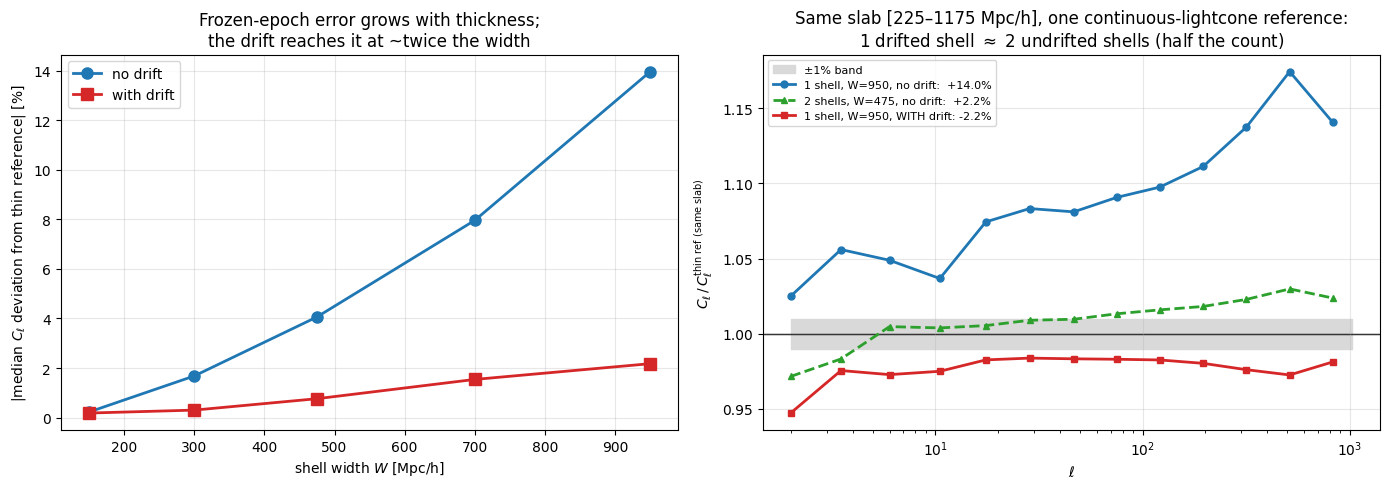

1 shell  W=950: no drift +13.96%, with drift -2.18%
2 shells W=475: no drift +2.23%


In [9]:
# Figure from the cached spectra (previous cell) -- restyle / re-render without re-simulating.
D = np.load(CACHE)
ell = D["ell"]
band = slice(10, len(ell) - 5)
res = {}
for W in WIDTHS:
    clr, cln, cld = D[f"clr_{int(W)}"], D[f"cln_{int(W)}"], D[f"cld_{int(W)}"]
    res[W] = dict(
        dev_no=float(np.median(cln[band] / clr[band]) - 1),
        dev_dr=float(np.median(cld[band] / clr[band]) - 1),
    )
common = {k: D[f"common_{k}"] for k in ("ref", "thick_no", "thick_dr", "two_no")}


def logbin(ell, y, nb=14):
    m = ell >= 2
    e, yy = ell[m], y[m]
    bins = np.unique(np.round(np.logspace(np.log10(2), np.log10(e.max()), nb)).astype(int))
    bc, bv = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (e >= lo) & (e < hi)
        if s.sum():
            bc.append(e[s].mean())
            bv.append(yy[s].mean())
    return np.array(bc), np.array(bv)


def dev(c):
    return float(np.median(c[band] / common["ref"][band]) - 1)


fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

# (a) per-width error vs shell width (each width vs its own thin reference)
Ws = np.array(WIDTHS)
axA.plot(Ws, [abs(res[W]["dev_no"]) * 100 for W in WIDTHS], "C0o-", lw=2, ms=8, label="no drift")
axA.plot(Ws, [abs(res[W]["dev_dr"]) * 100 for W in WIDTHS], "C3s-", lw=2, ms=8, label="with drift")
axA.set_xlabel("shell width $W$ [Mpc/h]")
axA.set_ylabel(r"|median $C_\ell$ deviation from thin reference| [%]")
axA.set_title("Frozen-epoch error grows with thickness;\nthe drift reaches it at ~twice the width")
axA.legend()
axA.grid(alpha=0.3)

# (b) one fixed slab, ONE shared thin-shell reference: 1 drifted shell vs 2 undrifted shells
bc, r_no1 = logbin(ell, common["thick_no"] / common["ref"])
_, r_no2 = logbin(ell, common["two_no"] / common["ref"])
_, r_dr1 = logbin(ell, common["thick_dr"] / common["ref"])
axB.fill_between([2, ell.max()], 0.99, 1.01, color="0.85", zorder=0, label="±1% band")
axB.axhline(1.0, color="k", lw=1.0, zorder=1)
axB.semilogx(bc, r_no1, "C0o-", lw=2, ms=5, label=f"1 shell, W=950, no drift:  {dev(common['thick_no']):+.1%}")
axB.semilogx(bc, r_no2, "C2^--", lw=2, ms=5, label=f"2 shells, W=475, no drift:  {dev(common['two_no']):+.1%}")
axB.semilogx(bc, r_dr1, "C3s-", lw=2, ms=5, label=f"1 shell, W=950, WITH drift: {dev(common['thick_dr']):+.1%}")
axB.set_xlabel(r"$\ell$")
axB.set_ylabel(r"$C_\ell \,/\, C_\ell^{\mathrm{thin\ ref\ (same\ slab)}}$")
axB.set_title(
    "Same slab [225–1175 Mpc/h], one continuous-lightcone reference:\n"
    "1 drifted shell $\\approx$ 2 undrifted shells (half the count)"
)
axB.legend(fontsize=8, loc="upper left")
axB.grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(f"1 shell  W=950: no drift {dev(common['thick_no']):+.2%}, with drift {dev(common['thick_dr']):+.2%}")
print(f"2 shells W=475: no drift {dev(common['two_no']):+.2%}")

### Takeaway

**The drift lets you use about half as many shells for the density field.** The frozen-epoch error
of a single shell grows with its width — from `+1.7%` at 300 Mpc/h to `+14%` at 950 Mpc/h *without*
drift — while the drift holds it to within `≈2%` across the whole range (panel a).

Posed apples-to-apples on one slab against a single continuous-lightcone reference (panel b):

| tiling of the slab [225–1175 Mpc/h] | median $C_\ell$ deviation |
|---|---|
| 1 shell, $W=950$, no drift | +14.0% |
| 2 shells, $W=475$, no drift | +2.2% |
| **1 shell, $W=950$, with drift** | **&minus;2.2%** |

So **one drifted thick shell ($-2.2\%$) matches two undrifted shells ($+2.2\%$)** — the drift buys
a factor $\approx 2$ in shell count for a fixed accuracy. (The median hides a scale dependence:
without drift the error climbs from a few percent at low $\ell$ to $\sim$17% at $\ell\sim10^{3}$;
the drift stays flat.)

**For Born convergence $\kappa$ the drift gives no improvement** &mdash; there the coarse-shell
error is the radial line-of-sight projection, not the per-shell redshift assignment, and a sub-Mpc
drift cannot fix it. See the lensing notebook.

## Next

[7 &middot; Advanced PM](07-Advanced-PM.ipynb) adds the PGD small-scale correction and compares
shell-partitioning strategies (equal width vs equal volume).